<a href="https://colab.research.google.com/github/AichaELMouta/Books_sales_Regression/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho


In [2]:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
#import all regression models to comparing metric values
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn import metrics

Loading Dataset from csv file to pandas dataframe

In [4]:
car_data=pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/car data.csv")

In [5]:
#Inspecting data
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
car_data.shape

(301, 9)

In [7]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
#show duplicated rows
car_data[car_data.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


Drop duplicates rows

In [9]:
#drop duplicated rows
car_data.drop_duplicates(inplace=True)
car_data = car_data.reset_index(drop=True)
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
294,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
295,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
296,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
297,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [10]:
car_data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [11]:
car_data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [12]:
car_data.Car_Name.value_counts()

,count
Car_Name,
city,26
corolla altis,16
verna,14
brio,10
fortuner,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1


In [13]:
#checking the categorical data
print(car_data.Fuel_Type.value_counts())
print(car_data.Transmission.value_counts())
print(car_data.Seller_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64


In [14]:
car_data.Owner.value_counts()

,count
Owner,
0,288
1,10
3,1


Exploratory DATA Analysis EDA with statistics

In [15]:
# statistical measures of the dataset
car_data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Test Each variable


1.   Transmission







In [16]:
# number of values for each brand
import plotly.express as px
px.histogram(car_data , x = 'Transmission' ,  text_auto = '.1f' , title = 'Transmission Range')

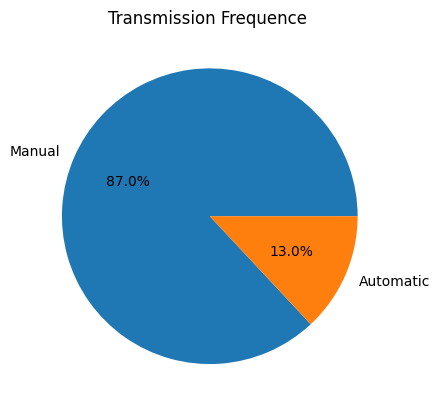

In [17]:
percentages = car_data['Transmission'].value_counts(normalize=True) * 100
plt.pie(percentages, labels=percentages.index,
        autopct='%1.1f%%')
plt.title('Transmission Frequence ')
plt.show()

In [18]:
from scipy.stats import ttest_ind
group1 = car_data[car_data['Transmission']=="Manual"]['Selling_Price']
group2 = car_data[car_data['Transmission']=="Automatic"]['Selling_Price']
results = ttest_ind(group1, group2)
print('Degree of Freedom:', {results.df})
print('p-value:', {results.pvalue})
print('t-statistic:', {results.statistic})


Degree of Freedom: {np.float64(297.0)}
p-value: {np.float64(5.532298979959338e-10)}
t-statistic: {np.float64(-6.415357573143541)}


1- P_value

P_value << 0.05  that means we can reject the null hypothesis because the difference between the two groups is statistically significant. based on p_value result we can conclude that transmission variable affects the selling price of cars.

2- T_statistic

t_statistic = -6.415  is very strong separation that means Manual Transmission and Automatic transmission have different average.

3- Degree of freedom

df = 297

The test is reliable



In [19]:
car_data.groupby('Transmission')['Selling_Price'].mean()

,Selling_Price
Transmission,
Automatic,9.071795
Manual,3.917308


The group means indicate that Automatic cars have a higher average 9.07 compared to those Manual cars.
This suggests that this feature contains meaningful predictive information and should be considered in the modeling phase.

In [20]:
def cohens_d(group1, group2):
  group1 = car_data[car_data['Transmission']=="Manual"]['Selling_Price']
  group2 = car_data[car_data['Transmission']=="Automatic"]['Selling_Price']
  n1, n2 = len(group1), len(group2)
  s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
  pooled_std = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
  return (np.mean(group1) - np.mean(group2)) / pooled_std
cohens_d(group1, group2)

np.float64(-1.1016343884869506)

Cohen's d = 1.01  based on this parameter of Cohens_d we can say that transmission variable is a strong predictor for car selling price.

    2- Seller Type

In [21]:
# Seller Type Variable
px.histogram(car_data , x = 'Seller_Type' ,  text_auto = '.1f' , title = 'Seller Type Range')

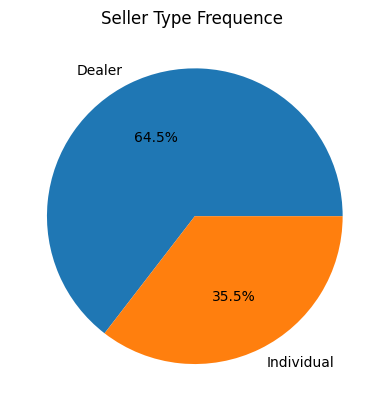

In [22]:
pourcentages = car_data['Seller_Type'].value_counts(normalize=True) * 100
plt.pie(pourcentages, labels=pourcentages.index,
        autopct='%1.1f%%')
plt.title('Seller Type Frequence ')
plt.show()

Hypothesis test and statistical analysis

In [23]:
group1 = car_data[car_data['Seller_Type']=="Individual"]['Selling_Price']
group2 = car_data[car_data['Seller_Type']=="Dealer"]['Selling_Price']
results = ttest_ind(group1, group2)
print('P_value:', {results.pvalue})
print('T_statistic:', {results.statistic})
print('Degree of Freedom:', {results.df})

P_value: {np.float64(1.952899027516022e-25)}
T_statistic: {np.float64(-11.463733809180827)}
Degree of Freedom: {np.float64(297.0)}


 1- P_value

P_value = 1.95e-25 << 0.05 that means we can reject the null hypothesis because the difference between the two groups is statistically significant. based on p_value result we can conclude that Seller Type variable affects the selling price of cars.

2- T_statistic

t_statistic = -11.46 is very strong separation that means Dealer seller  and Individual seller have different average.

3- Degree of freedom

df = 297

The test is reliable

In [24]:
car_data.groupby('Seller_Type')['Selling_Price'].mean()

,Selling_Price
Seller_Type,
Dealer,6.632021
Individual,0.870943


The group means indicate that Dealer seller have a higher average 6.63 compared to those Individual seller. This suggests that this feature contains meaningful predictive information and should be considered in the modeling phase.

In [25]:
#Cohens_d parameter
def cohens_d(group1, group2):
  group1 = car_data[car_data['Seller_Type']=="Dealer"]['Selling_Price']
  group2 = car_data[car_data['Seller_Type']=="Individual"]['Selling_Price']
  n1, n2 = len(group1), len(group2)
  s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
  pooled_std = np.sqrt(((n1 -n2) * s1 + (n2 - n1) * s2) / (n1 + n2 - 2))
  return (np.mean(group1) - np.mean(group2)) / pooled_std
cohens_d(group1, group2)


np.float64(2.240413224585212)

Cohens_d = 2.24  based on this parameter of Cohens_d we can say that seller type variable is a strong predictor for car selling price.

3- Fuel Type

In [26]:
px.histogram(car_data , x = 'Fuel_Type' ,  text_auto = '.1f' , title = 'Fuel type Range')

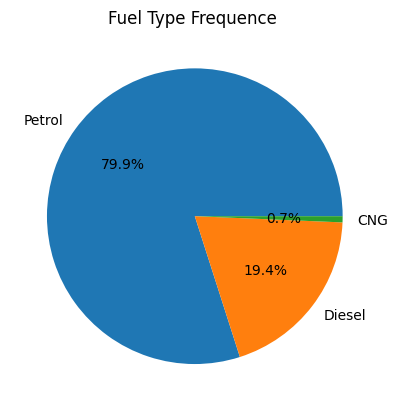

In [27]:
pourcentages = car_data['Fuel_Type'].value_counts(normalize=True) * 100
plt.pie(pourcentages, labels=pourcentages.index,
        autopct='%1.1f%%')
plt.title('Fuel Type Frequence ')
plt.show()

Test of null hypothesis and statistical analysis

In [28]:
from scipy.stats import f_oneway
group1 = car_data[car_data['Fuel_Type']=="Petrol"]['Selling_Price']
group2 = car_data[car_data['Fuel_Type']=="Diesel"]['Selling_Price']
group3 = car_data[car_data['Fuel_Type']=="CNG"]['Selling_Price']
F_stat, p_value = f_oneway(group1, group2, group3)
print('p_value', p_value)
print('F_stat', F_stat)

p_value 3.1012300197759416e-23
F_stat 62.061249891630744


1- P_value

P_value = 3.10e-23 << 0.05 that means we can reject the null hypothesis because the difference between groups is statistically significant. based on p_value result we can conclude that Fuel Type variable affects the selling price of cars.

2- F_statistic

t_statistic = 62.06 is very strong difference between groups.

In [29]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=car_data['Selling_Price'],
    groups=car_data['Fuel_Type'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   CNG Diesel   7.0028 0.0547 -0.1087 14.1143  False
   CNG Petrol   0.1642 0.9983  -6.857  7.1853  False
Diesel Petrol  -6.8386    0.0 -8.2859 -5.3912   True
----------------------------------------------------


Based in Turkey HSD results we can say that CNG and Petrol have same behavior, but Petrol and Diesel are very different. So Fuel Type categorical feature is not random noise. Fuel Type contains real predictive information.

Owner

In [30]:
px.histogram(car_data , x = 'Owner' ,  text_auto = '.1f' , title = 'Owner Range')

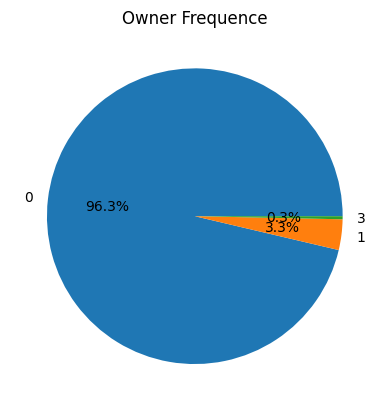

In [31]:
pourcentages = car_data['Owner'].value_counts(normalize=True) * 100
plt.pie(pourcentages, labels=pourcentages.index,
        autopct='%1.1f%%')
plt.title('Owner Frequence')
plt.show()

In [32]:
from scipy.stats import spearmanr
spearman_corr, p_value = spearmanr(car_data['Owner'], car_data['Selling_Price'])
print('Spearman correlation coefficient:', spearman_corr)
print('p-value:', p_value)

Spearman correlation coefficient: -0.14346639205485182
p-value: 0.013019562211863142


A Spearman correlation test showed a statistically significant negative relationship between the number of previous owners and selling price (ρ = −0.143, p = 0.013). However, the effect size is very weak, indicating that while cars with more owners tend to sell for slightly lower prices, the Owner variable has limited practical predictive power. We can test also by using ANOVA.

In [33]:
from scipy.stats import f_oneway
group1 = car_data[car_data['Owner']=="0"]['Selling_Price']
group2 = car_data[car_data['Owner']=="1"]['Selling_Price']
group3 = car_data[car_data['Owner']=="3+"]['Selling_Price']
group4 = car_data[car_data['Owner']=="2"]['Selling_Price']


In [34]:
px.histogram(car_data , x = 'Car_Name' ,  text_auto = '.1f' , title = 'Car Name Range')

In [35]:
px.histogram(car_data , x = 'Year' ,  text_auto = '.1f' , title = 'Year Range')

In [36]:
#Convert Year to Age
np.max(car_data['Year'])
#To calculate the age of cars, 2019 will be considered the reference year.
car_data['Age'] = 2019 - car_data['Year']
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...,...,...
294,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,3
295,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
296,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,10
297,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,2


In [37]:
print('Skewness coeficient',car_data['Age'].skew())
print('The number of Null Value of Age variable',(car_data['Age'] == 0).sum())

Skewness coeficient 1.2368759011841435
The number of Null Value of Age variable 0


<Axes: xlabel='Age', ylabel='Count'>

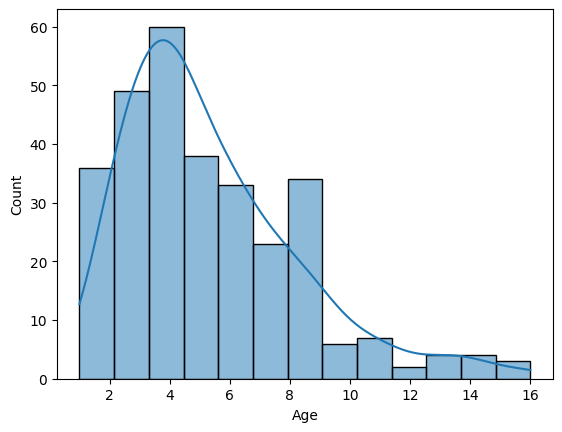

In [38]:
sns.histplot(car_data['Age'], kde=True)

Based on the coefficient of skewness of Age variable and graph, we can conclude that the age is strong posively skewness (right skewness). We could use Log transformation to reduce skewness.

Coeficient Log age: 0.03175096427821029


<Axes: xlabel='Age', ylabel='Count'>

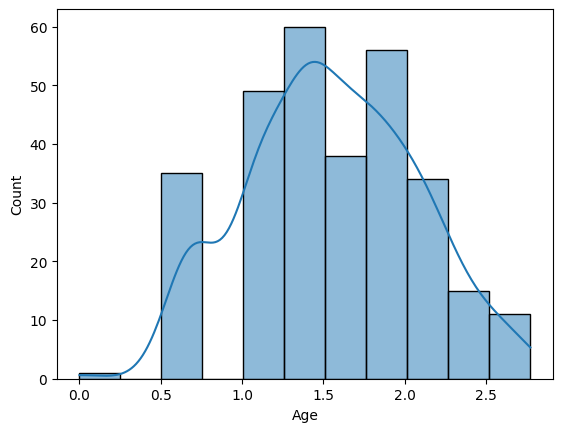

In [39]:
print('Coeficient Log age:', np.log(car_data['Age']).skew())
sns.histplot(np.log(car_data['Age']), kde=True)

In [40]:
car_data['Log_Age'] = np.log(car_data['Age'])

In [41]:
px.scatter(car_data, x='Log_Age', y='Selling_Price',  height = 600 , width =1000 ,title = 'Log age Vs Selling Price', size='Selling_Price', template = 'plotly_dark')

In [42]:
# Calculate the correlation matrix
import scipy.stats as stats
correlation_coefficient, p_value = stats.pearsonr(car_data['Log_Age'], car_data['Selling_Price'])

print(f"SciPy Pearson correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

SciPy Pearson correlation coefficient: -0.23400034024454408
P-value: 4.385564275215162e-05


Based in this resulat r = -0,234 AND p-value = 4.3855e-05, we can conclude that there is a statistically significant but weak negative linear relationship between Age and Selling price.

 Kms_Driven

In [66]:
px.histogram(car_data , x = 'Kms_Driven',  text_auto = '.1f' , title = 'Kms Driven Range')

In [67]:
car_data['Kms_Driven'].skew()

np.float64(6.418134387971488)

<Axes: xlabel='Kms_Driven', ylabel='Count'>

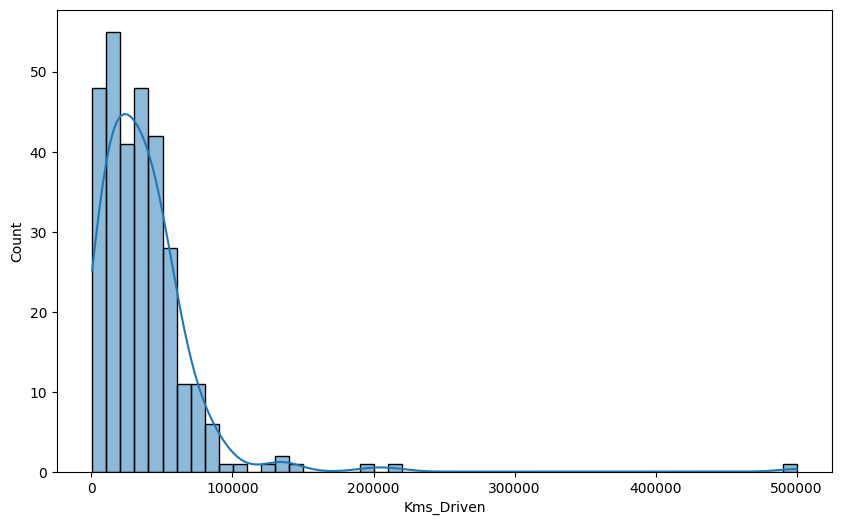

In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(car_data['Kms_Driven'], kde=True)

In [69]:
(car_data['Kms_Driven'] == 0).sum()

np.int64(0)

In [70]:
np.log(car_data['Kms_Driven']).skew()

np.float64(-1.0394083295200534)

-1.04 means strong negative skew (left skew)

<Axes: xlabel='Kms_Driven', ylabel='Count'>

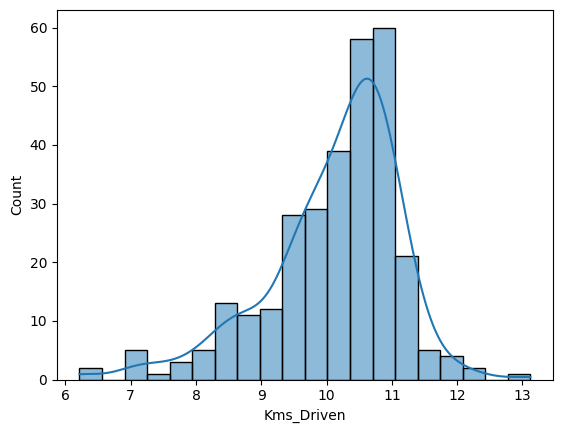

In [71]:
sns.histplot(np.log(car_data['Kms_Driven']), kde=True)

In [72]:
car_data['Log_Kms_Driven'] = np.log(car_data['Kms_Driven'])

In [73]:
correlation_coefficient, p_value = stats.pearsonr(car_data['Log_Kms_Driven'], car_data['Selling_Price'])

print(f"SciPy Pearson correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

SciPy Pearson correlation coefficient: 0.12122449510185697
P-value: 0.03616033603968142


In [75]:
px.scatter(car_data, x= 'Kms_Driven', y = 'Selling_Price', height = 600, width = 1000, title = 'Kms_Driven vs Selling Price', size = 'Selling_Price', template = 'plotly_dark')

In [77]:
px.scatter(car_data, x= 'Log_Kms_Driven', y = 'Selling_Price', height = 600, width = 1000, title= 'Log_Kms_Driven vs Selling Price', size = 'Selling_Price', template = 'plotly_dark')

Based in resulats and graphs we can conclude that there is a statistically significant but very weak positive linear relationship between kms_driven and selling price. that means the variable alone is a poor predictor but it may still contribute slightly in ML models.

In [45]:
px.scatter (car_data , x = 'Present_Price' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Present Price Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )

In [78]:
correlation_coefficient, p_value = stats.pearsonr(car_data['Present_Price'], car_data['Selling_Price'])

print(f"SciPy Pearson correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

SciPy Pearson correlation coefficient: 0.876378180060999
P-value: 3.063866979552786e-96


There is a statistically significant but very weak positive linear relationship between Present price and selling price.

***Data*** **Encoding**
```Encoder categorical variables```



In [43]:
#encoder = LabelEncoder()
#car_data['Transmission'] = encoder.fit_transform(car_data['Transmission'])
#car_data['Fuel_Type'] = encoder.fit_transform(car_data['Fuel_Type'])
#car_data['Seller_Type'] = encoder.fit_transform(car_data['Seller_Type'])


In [44]:
#car_data

Bivariate Analysis

In [46]:
px.scatter (car_data , x = 'Car_Name' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Car Name Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )

In [47]:
px.scatter(car_data, x= 'Kms_Driven', y = 'Selling_Price', height = 600, width = 1000, title = 'Kms_Driven vs Selling Price', size = 'Selling_Price', template = 'plotly_dark')

In [48]:
px.scatter (car_data , x = 'Fuel_Type' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Fuel Type Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )


In [49]:
px.scatter (car_data , x = 'Seller_Type' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Seller Type Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )


In [50]:
px.scatter (car_data , x = 'Transmission' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Transmission Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )


In [51]:
px.scatter (car_data , x = 'Owner' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Owner Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )


In [52]:
px.scatter (car_data , x = 'Age' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Age Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )


Statistics analysis

<Axes: xlabel='Age', ylabel='Count'>

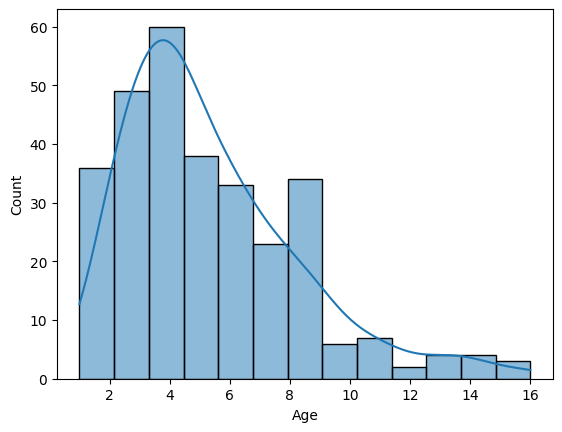

In [53]:
sns.histplot(car_data['Age'], kde=True)


In [54]:
car_data['Age'].skew()


np.float64(1.2368759011841435)

In [55]:
car_data['Age'].max() / car_data['Age'].min()

16.0

<Axes: xlabel='Age', ylabel='Selling_Price'>

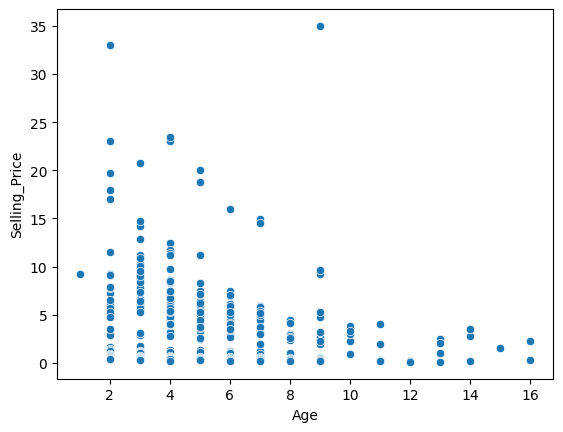

In [56]:
sns.scatterplot(x=car_data['Age'], y=car_data['Selling_Price'])


<Axes: xlabel='Age', ylabel='Selling_Price'>

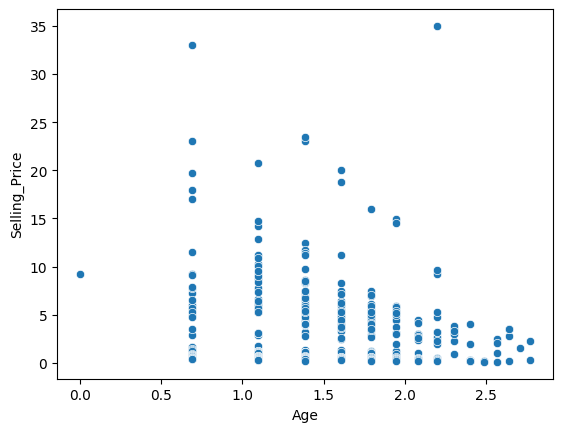

In [57]:
sns.scatterplot(x=np.log(car_data['Age']), y=car_data['Selling_Price'])


In [58]:
(car_data['Age'] == 0).sum()


np.int64(0)

<Axes: xlabel='Age', ylabel='Count'>

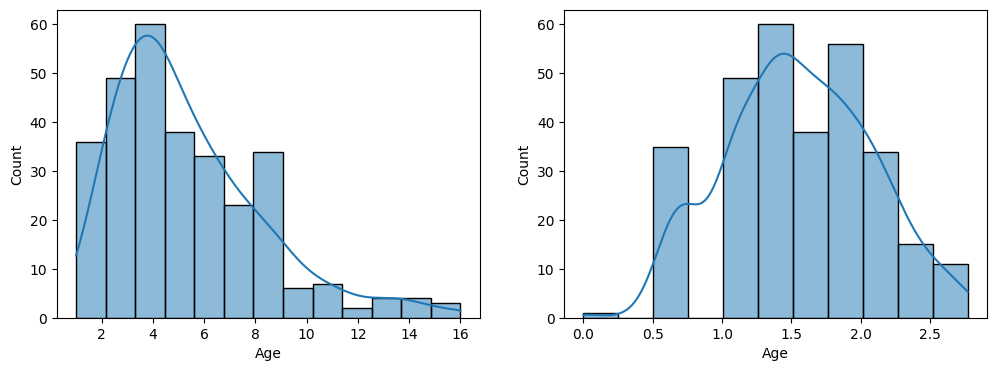

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(car_data['Age'], kde=True, ax=ax[0])
sns.histplot(np.log(car_data['Age']), kde=True, ax=ax[1])


In [60]:
car_data['Age'].skew(), np.log(car_data['Age']).skew(), np.log1p(car_data['Age']).skew()


(np.float64(1.2368759011841435),
 np.float64(0.03175096427821029),
 np.float64(0.24098467841634508))

In [61]:
(car_data['Kms_Driven'] == 0).sum()

np.int64(0)

In [62]:
car_data['Kms_Driven'].skew(), np.log(car_data['Kms_Driven'].skew())

(np.float64(6.418134387971488), np.float64(1.8591274816974062))

<Axes: xlabel='Kms_Driven', ylabel='Count'>

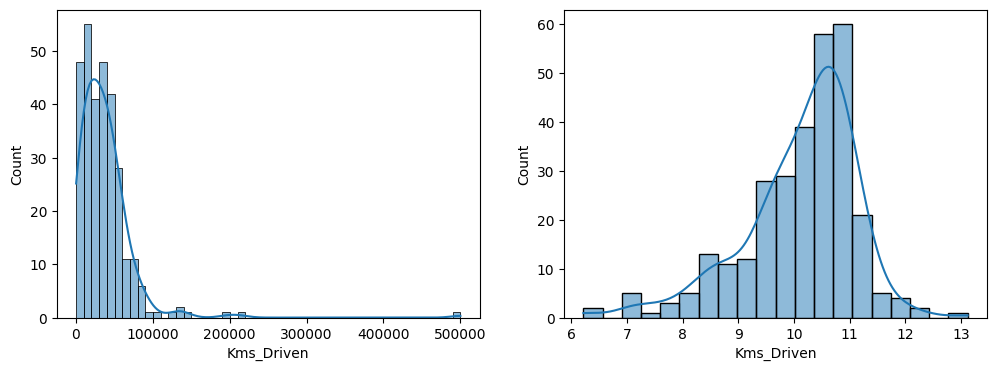

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(car_data['Kms_Driven'], kde=True, ax=ax[0])
sns.histplot(np.log(car_data['Kms_Driven']), kde=True, ax=ax[1])



<Axes: xlabel='Kms_Driven', ylabel='Selling_Price'>

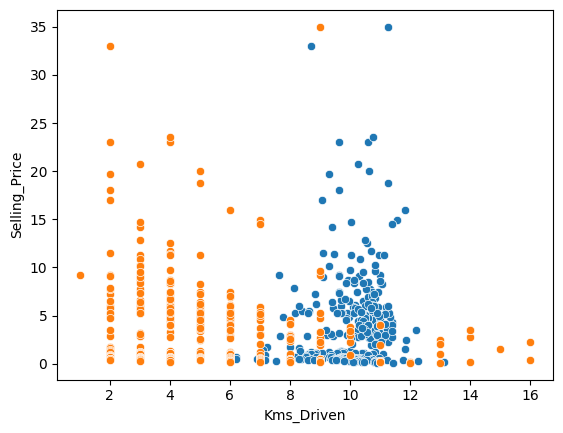

In [64]:
sns.scatterplot(x=np.log(car_data['Kms_Driven']), y=car_data['Selling_Price'])
sns.scatterplot(x=car_data['Age'], y=car_data['Selling_Price'])


**Data Scaling**


**Splitting** **Data**

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

NameError: name 'X' is not defined

In [ ]:
X_train.shape

In [ ]:
X_test.shape

**Model Training**

*Linear Regression*


In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

In [ ]:
lr_predict_train = lr.predict(X_train)
lr_predict_test = lr.predict(X_test)

In [ ]:
mae_tr = metrics.mean_absolute_error(Y_train, lr_predict_train)
rmse_tr_lr = np.sqrt(metrics.mean_squared_error(Y_train, lr_predict_train))
mae_ts = metrics.mean_absolute_error(Y_test, lr_predict_test)
rmse_ts = np.sqrt(metrics.mean_squared_error(Y_test, lr_predict_test))
print("MAE of train data:", mae_tr)
print("MAE of test data:", mae_ts)
print("RMSE of train data:", rmse_tr_lr)
print("RMSE of test data:", rmse_ts)


*Lasso* *Regression*

In [ ]:
lasso_model = Lasso()
lasso_model.fit(X_train, Y_train)

In [ ]:
lasso_model_predict_train = lasso_model.predict(X_train)
lasso_model_predict_test = lasso_model.predict(X_test)


In [ ]:
mae_tr = metrics.mean_absolute_error(Y_train, lasso_model_predict_train)
rmse_tr_lasso = np.sqrt(metrics.mean_squared_error(Y_train, lasso_model_predict_train))
mae_ts = metrics.mean_absolute_error(Y_test, lasso_model_predict_test)
rmse_ts = np.sqrt(metrics.mean_squared_error(Y_test, lasso_model_predict_test))
print("MAE of train data:", mae_tr)
print("MAE of test data:", mae_ts)
print("RMSE of train data:", rmse_tr_lasso)
print("RMSE of test data:", rmse_ts)

*Ridge Regression*

In [ ]:
ridge_model = Ridge()
ridge_model.fit(X_train, Y_train)

In [ ]:
ridge_model_predict_train = ridge_model.predict(X_train)
ridge_model_predict_test = ridge_model.predict(X_test)

In [ ]:
mae_tr = metrics.mean_absolute_error(Y_train, ridge_model_predict_train)
rmse_tr_ridge = np.sqrt(metrics.mean_squared_error(Y_train, ridge_model_predict_train))
mae_ts = metrics.mean_absolute_error(Y_test, lr_predict_test)
rmse_ts = np.sqrt(metrics.mean_squared_error(Y_test, lr_predict_test))
print("MAE of train data:", mae_tr)
print("MAE of test data:", mae_ts)
print("RMSE of train data:", rmse_tr_ridge)
print("RMSE of test data:", rmse_ts)


*ElasticNet Regression*




In [ ]:
modelelastic = ElasticNet(alpha = 1.0, l1_ratio=0.5)
modelelastic.fit(X_train, Y_train)

In [ ]:
modelelastic_predict_train = modelelastic.predict(X_train)
modelelastic_predict_test = modelelastic.predict(X_test)

In [ ]:
mae_tr_els = metrics.mean_absolute_error(Y_train, modelelastic_predict_train)
rmse_tr_els = np.sqrt(metrics.mean_squared_error(Y_train, modelelastic_predict_train))
mae_els = metrics.mean_absolute_error(Y_test, modelelastic_predict_test)
rmse_els = np.sqrt(metrics.mean_squared_error(Y_test, modelelastic_predict_test))
print("MAE of train data:", mae_tr_els)
print("MAE of test data:", mae_els)
print("RMSE of train data:", rmse_tr_els)
print("RMSE of test data:", rmse_els)

In [ ]:
print("RMSE LR:", rmse_tr_lr)
print("RMSE Lasso:", rmse_tr_lasso)
print("RMSE Ridge:", rmse_tr_ridge)
print("RMSE ElasticNet:", rmse_tr_els)


In [ ]:
rmse_values = {
    'Linear': rmse_tr_lr,
    'Lasso': rmse_tr_lasso,
    'Ridge': rmse_tr_ridge,
    'ElasticNet': rmse_tr_els
}

plt.figure(figsize=(7,5))
plt.bar(rmse_values.keys(), rmse_values.values(), color = 'green')
plt.ylabel("Test RMSE")
plt.title("Model Comparison Using RMSE (Lower is Better)")
plt.show()

Based on linear regression models, Ridge, Lasso and ElasticNet and thier RMSE, the best model for predicting car prices in this dataset is Ridge Model. Both Ridge and linear regression show the lowest and nearly identical RMSE score, indicationg that the model's prediction error is approximately ±27,274 dollars. This means the model typically predicts car prices with an average deviation of about 27.274 from the actual value.